# DeepHit Backtest Grid Search Analysis

Load the threshold grid-search results and inspect the trade-off between implementation shortfall, participation, fills, and cancellations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [11]:
RESULT_CANDIDATES = [
    Path("../reports/deephit_threshold_grid_search.csv"),
    Path("reports/deephit_threshold_grid_search.csv"),
]
RESULT_PATH = next((path for path in RESULT_CANDIDATES if path.exists()), RESULT_CANDIDATES[0])

df = pd.read_csv(RESULT_PATH)
df = df.sort_values(["max_toxic_probability", "min_fill_probability"]).reset_index(drop=True)

print(f"Loaded {len(df):,} grid rows from {RESULT_PATH}")
display(df.head())

Loaded 35 grid rows from ../reports/deephit_threshold_grid_search.csv


,orders,submitted_orders,skipped_orders,filled_orders,unfilled_orders,canceled_orders,metric_ok_orders,metric_failed_orders,fill_rate,mean_implementation_shortfall_bps,median_implementation_shortfall_bps,total_implementation_shortfall,total_implementation_shortfall_raw,opportunity_cost_count,opportunity_cost_mean_bps,toxic_cost_count,toxic_cost_mean_bps,max_toxic_probability,min_fill_probability,horizon_index,cache_size,cache_hits,cache_misses
0,"4,000.0000","2,913.0000","1,087.0000","1,933.0000",980.0000,980.0000,"4,000.0000",0.0000,0.6636,-0.5777,-0.3802,-60.2500,"-60,250,000,960.0000","2,067.0000",-0.7784,"1,933.0000",-0.3632,0.2200,0.5000,9,18886,402920,18886
1,"4,000.0000","2,913.0000","1,087.0000","1,933.0000",980.0000,980.0000,"4,000.0000",0.0000,0.6636,-0.5781,-0.3802,-60.2900,"-60,290,002,496.0000","2,067.0000",-0.7791,"1,933.0000",-0.3632,0.2200,0.6000,9,18886,410683,18886
2,"4,000.0000","2,913.0000","1,087.0000","1,932.0000",981.0000,981.0000,"4,000.0000",0.0000,0.6632,-0.5789,-0.3802,-60.3750,"-60,374,995,840.0000","2,068.0000",-0.7806,"1,932.0000",-0.3631,0.2200,0.7000,9,18886,418442,18886
3,"4,000.0000","2,913.0000","1,087.0000","1,922.0000",991.0000,991.0000,"4,000.0000",0.0000,0.6598,-0.5795,-0.3802,-60.4350,"-60,435,017,024.0000","2,078.0000",-0.7834,"1,922.0000",-0.3591,0.2200,0.8000,9,18886,426170,18886
4,"4,000.0000","2,777.0000","1,223.0000","1,465.0000","1,312.0000","1,312.0000","4,000.0000",0.0000,0.5275,-0.5730,-0.3849,-59.7399,"-59,739,913,024.0000","2,535.0000",-0.7051,"1,465.0000",-0.3443,0.2200,0.9000,9,18886,433371,18886


In [12]:
df["submitted_rate"] = df["submitted_orders"] / df["orders"]
df["skipped_rate"] = df["skipped_orders"] / df["orders"]
df["canceled_rate"] = df.get("canceled_orders", 0) / df["orders"]
df["metric_failed_rate"] = df.get("metric_failed_orders", 0) / df["orders"]

ranking_cols = [
    "max_toxic_probability",
    "min_fill_probability",
    "mean_implementation_shortfall_bps",
    "median_implementation_shortfall_bps",
    "submitted_orders",
    "submitted_rate",
    "filled_orders",
    "canceled_orders",
    "fill_rate",
    "opportunity_cost_mean_bps",
    "toxic_cost_mean_bps",
    "metric_failed_rate",
]
ranking_cols = [c for c in ranking_cols if c in df.columns]

best = df.sort_values("mean_implementation_shortfall_bps", ascending=True)
display(best[ranking_cols].head(15))

,max_toxic_probability,min_fill_probability,mean_implementation_shortfall_bps,median_implementation_shortfall_bps,submitted_orders,submitted_rate,filled_orders,canceled_orders,fill_rate,opportunity_cost_mean_bps,toxic_cost_mean_bps,metric_failed_rate
11,0.2800,0.6000,-0.6007,-0.1923,"3,968.0000",0.9920,"3,501.0000",467.0000,0.8823,-2.4393,-0.3386,0.0000
17,0.3100,0.7000,-0.6003,-0.1921,"3,986.0000",0.9965,"3,593.0000",393.0000,0.9014,-2.8531,-0.3451,0.0000
10,0.2800,0.5000,-0.6002,-0.1923,"3,968.0000",0.9920,"3,502.0000",466.0000,0.8826,-2.4365,-0.3391,0.0000
27,0.3700,0.7000,-0.6000,-0.1921,"3,995.0000",0.9988,"3,634.0000",361.0000,0.9096,-3.0936,-0.3488,0.0000
32,0.4000,0.7000,-0.5993,-0.1920,"3,996.0000",0.9990,"3,637.0000",359.0000,0.9102,-3.1133,-0.3484,0.0000
12,0.2800,0.7000,-0.5989,-0.1923,"3,968.0000",0.9920,"3,490.0000",478.0000,0.8795,-2.4314,-0.3311,0.0000
22,0.3400,0.7000,-0.5979,-0.1921,"3,991.0000",0.9978,"3,621.0000",370.0000,0.9073,-2.9953,-0.3470,0.0000
25,0.3700,0.5000,-0.5950,-0.1913,"3,996.0000",0.9990,"3,711.0000",285.0000,0.9287,-3.5415,-0.3655,0.0000
28,0.3700,0.8000,-0.5950,-0.1922,"3,995.0000",0.9988,"3,526.0000",469.0000,0.8826,-2.6172,-0.3232,0.0000
18,0.3100,0.8000,-0.5949,-0.1922,"3,986.0000",0.9965,"3,501.0000",485.0000,0.8783,-2.5258,-0.3197,0.0000


In [13]:
def heatmap_table(value_col: str) -> pd.DataFrame:
    return df.pivot_table(
        index="max_toxic_probability",
        columns="min_fill_probability",
        values=value_col,
        aggfunc="mean",
    ).sort_index(ascending=False)


def plot_heatmap(value_col: str, title: str, cmap: str = "viridis", fmt: str = ".2f", center=None):
    table = heatmap_table(value_col)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(table, annot=True, fmt=fmt, cmap=cmap, center=center, linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("min_fill_probability")
    ax.set_ylabel("max_toxic_probability")
    plt.tight_layout()
    return ax

## Implementation Shortfall Heatmap

Lower is better under the current convention. Negative values mean favorable average shortfall.

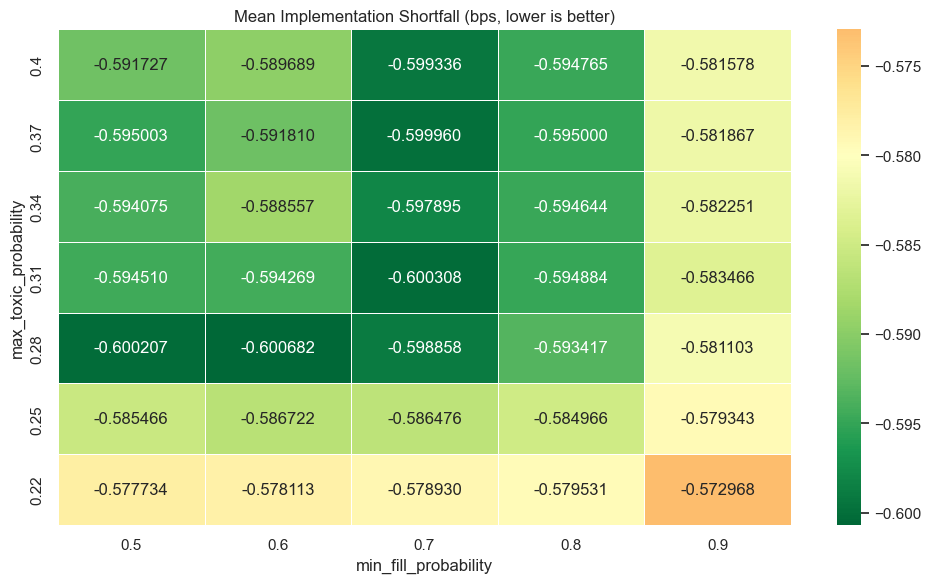

In [19]:
plot_heatmap(
    "mean_implementation_shortfall_bps",
    "Mean Implementation Shortfall (bps, lower is better)",
    cmap="RdYlGn_r",
    fmt=".6f",
    center=-0.58,
);

## Submitted Orders Heatmap

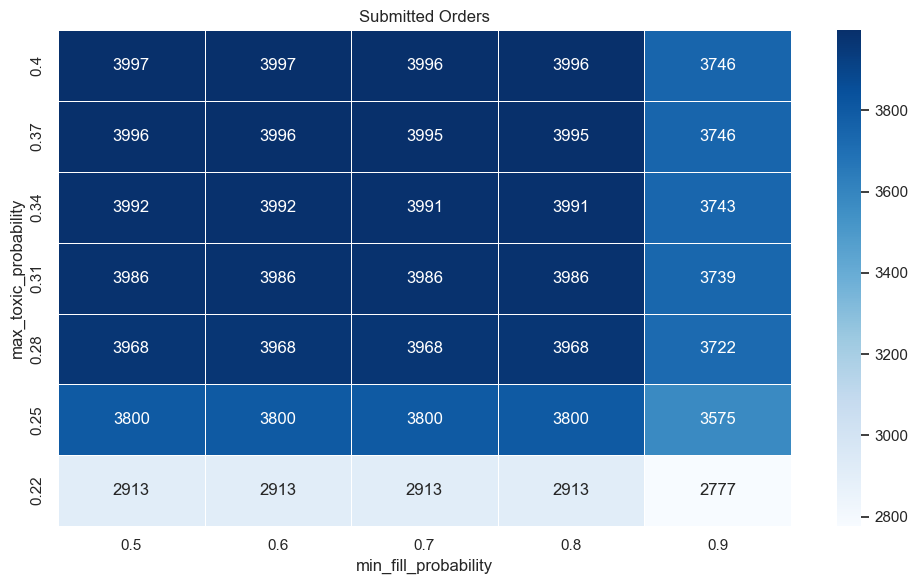

In [16]:
plot_heatmap(
    "submitted_orders",
    "Submitted Orders",
    cmap="Blues",
    fmt=".0f",
);

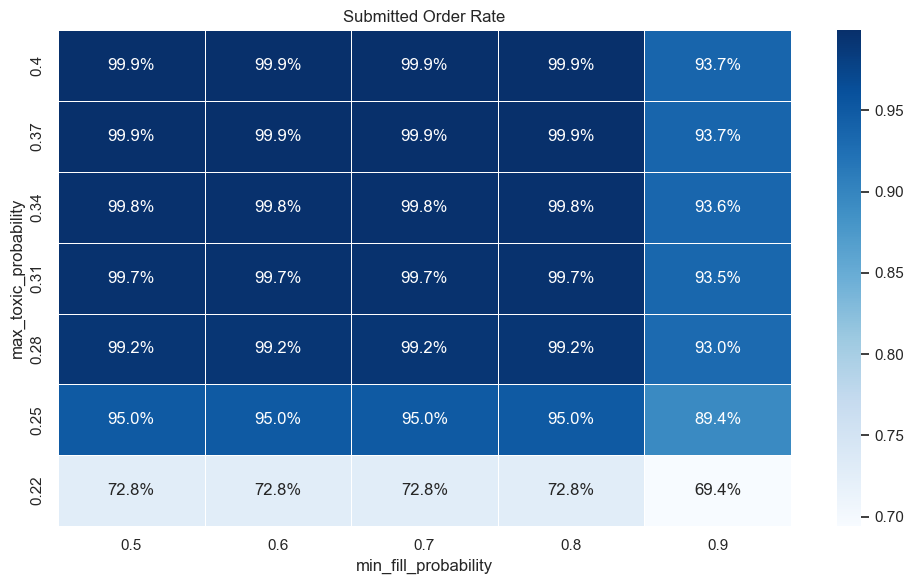

In [20]:
plot_heatmap(
    "submitted_rate",
    "Submitted Order Rate",
    cmap="Blues",
    fmt=".1%",
);

## Trade-Off Views

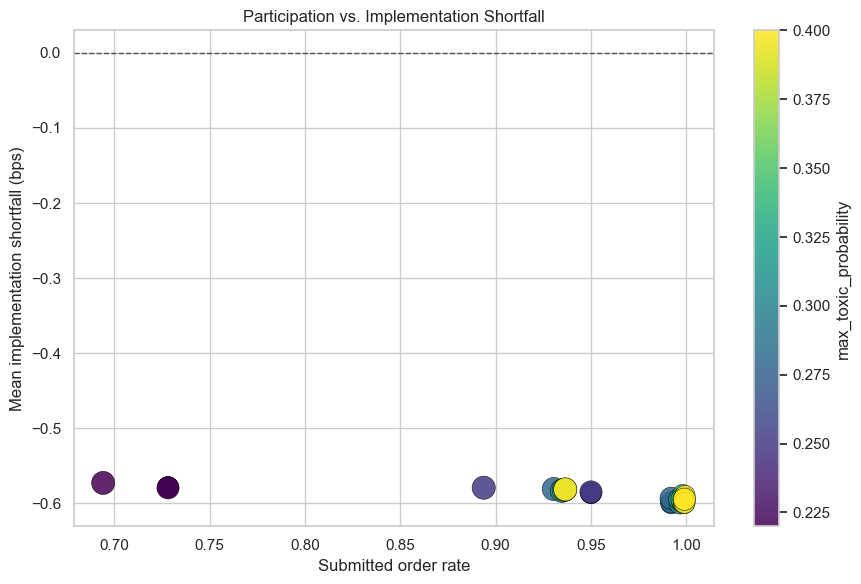

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    df["submitted_rate"],
    df["mean_implementation_shortfall_bps"],
    c=df["max_toxic_probability"],
    s=80 + 220 * df["min_fill_probability"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Submitted order rate")
ax.set_ylabel("Mean implementation shortfall (bps)")
ax.set_title("Participation vs. Implementation Shortfall")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("max_toxic_probability")
plt.tight_layout();

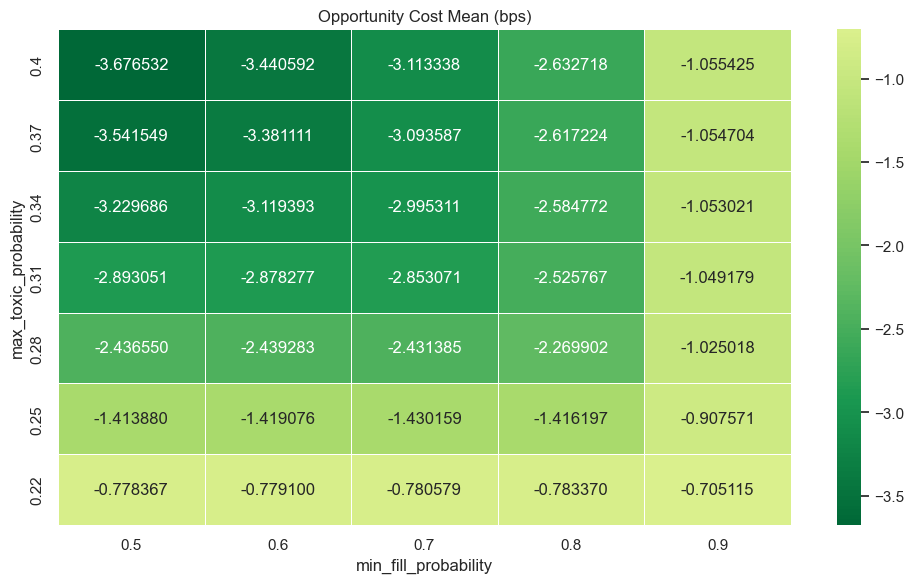

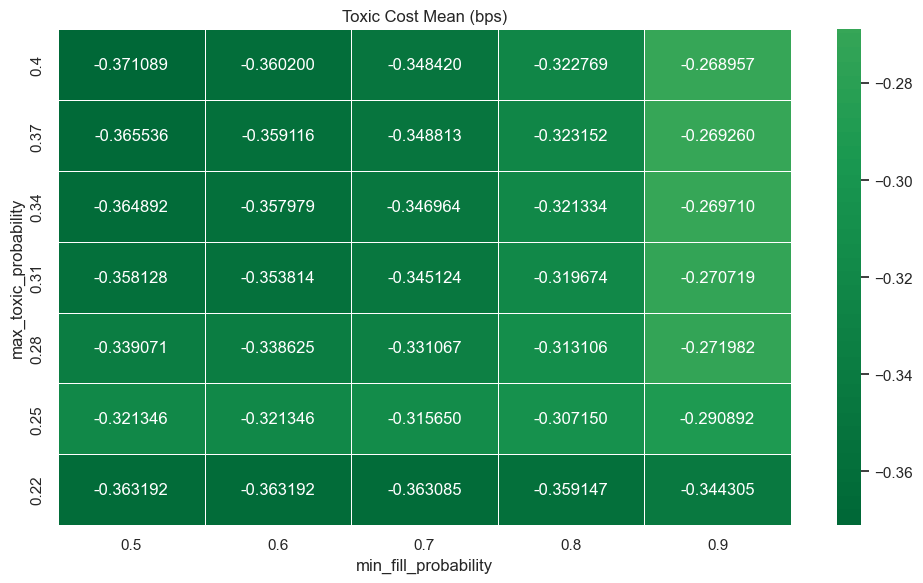

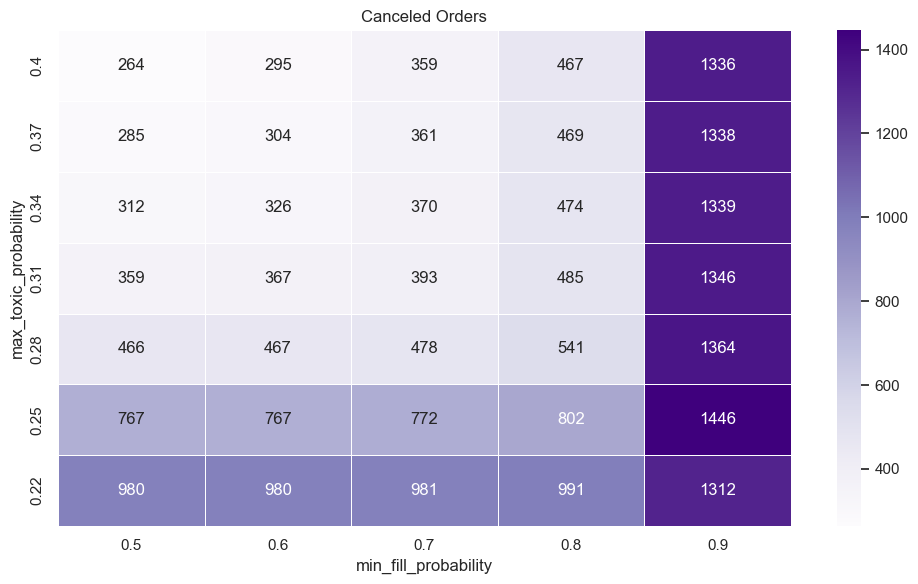

In [23]:
optional_heatmaps = [
    ("opportunity_cost_mean_bps", "Opportunity Cost Mean (bps)", "RdYlGn_r"),
    ("toxic_cost_mean_bps", "Toxic Cost Mean (bps)", "RdYlGn_r"),
    ("canceled_orders", "Canceled Orders", "Purples"),
]

for col, title, cmap in optional_heatmaps:
    if col in df.columns:
        plot_heatmap(col, title, cmap=cmap, fmt=".6f" if col.endswith("bps") else ".0f", center=0 if col.endswith("bps") else None)
        plt.show()

## Cache Diagnostics

The grid-search CSV is usually sorted by performance, so cumulative cache counters may not appear chronological. This view sorts by thresholds as a rough run-order proxy.

,max_toxic_probability,min_fill_probability,cache_size,cache_hits,cache_misses
0,0.1000,0.0000,4010,0,4010
1,0.1000,0.0500,4010,4010,4010
2,0.1000,0.1000,4010,8020,4010
3,0.1000,0.2000,4010,12030,4010
4,0.1000,0.3000,4010,16040,4010
5,0.1000,0.4000,4010,20050,4010
6,0.1500,0.0000,4140,24060,4140
7,0.1500,0.0500,4140,28200,4140
8,0.1500,0.1000,4140,32340,4140
9,0.1500,0.2000,4140,36480,4140


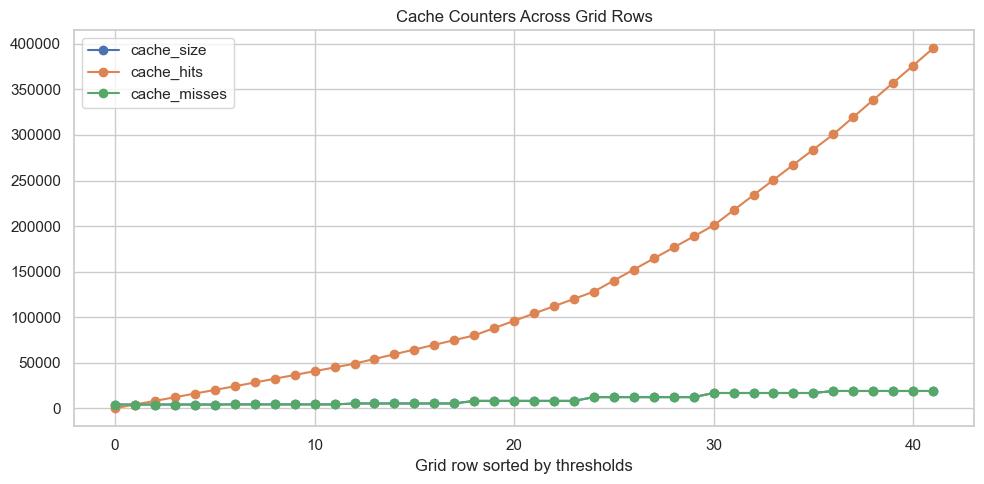

In [10]:
cache_cols = [c for c in ["max_toxic_probability", "min_fill_probability", "cache_size", "cache_hits", "cache_misses"] if c in df.columns]
if cache_cols:
    display(df[cache_cols].sort_values(["max_toxic_probability", "min_fill_probability"]))

    fig, ax = plt.subplots(figsize=(10, 5))
    for col in ["cache_size", "cache_hits", "cache_misses"]:
        if col in df.columns:
            ax.plot(df.sort_values(["max_toxic_probability", "min_fill_probability"])[col].to_numpy(), marker="o", label=col)
    ax.set_title("Cache Counters Across Grid Rows")
    ax.set_xlabel("Grid row sorted by thresholds")
    ax.legend()
    plt.tight_layout();